# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment) with Hyperparameter Tuning

## 1. Imports & Setup

In [1]:
import os
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelBinarizer, LabelEncoder, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

warnings.filterwarnings('ignore')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['figure.titlesize'] = 15

RANDOM_STATE = 42

def save_eps_figure(fig, filename, dpi=150, max_dim=850):
    png_file = f"{filename}.png"
    eps_file = f"{filename}.eps"
    
    fig.savefig(png_file, format='png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    img = Image.open(png_file)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    if max(img.size) > max_dim:
        ratio = max_dim / float(max(img.size))
        new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
        img = img.resize(new_size, Image.Resampling.LANCZOS)
        
    img.save(eps_file, 'EPS')
    print(f"Saved figure silently: {eps_file} ({os.path.getsize(eps_file)/(1024*1024):.2f} MB) and {png_file}")

print("Setup and rules.md font settings completed.")


Setup done.


## 2. Download & Load Dataset

In [2]:
import os
import zipfile
import io
import pandas as pd

zip_path = r'c:\Users\Balakumaran\ML-lab\Experiment9_copy\archive (9).zip'
if os.path.exists(zip_path):
    print(f"Using zip dataset: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as z:
        labels_df = pd.read_csv(io.BytesIO(z.read('english.csv')))
else:
    candidate_paths = [
        r'C:\Users\Balakumaran\Downloads\archive (9)',
        'archive (9)',
        '../archive (9)',
        r'c:\Users\Balakumaran\ML-lab\archive (9)'
    ]
    DATA_DIR = None
    for p in candidate_paths:
        if os.path.exists(os.path.join(p, 'english.csv')):
            DATA_DIR = os.path.abspath(p)
            break
    if DATA_DIR is None:
        raise FileNotFoundError("Couldn't find 'english.csv' or 'archive (9).zip'.")
    labels_df = pd.read_csv(os.path.join(DATA_DIR, 'english.csv'))
    print(f"Found dataset folder: {DATA_DIR}")
print(f"Found {len(labels_df)} labeled images across {labels_df['label'].nunique()} classes.")
display(labels_df.head())


Found 3410 labeled images across 62 classes.


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


## 3. Preprocessing: Load Images, Resize, Flatten, Normalize

In [3]:
IMG_SIZE = 32   # resize every character image to 32x32 grayscale before flattening

def load_and_preprocess_fast(labels_df, img_size=IMG_SIZE):
    images = []
    labels = []
    zip_path = r'c:\Users\Balakumaran\ML-lab\Experiment9_copy\archive (9).zip'
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            for _, row in labels_df.iterrows():
                img_bytes = z.read(row['image'])
                img = Image.open(io.BytesIO(img_bytes)).convert('L').resize((img_size, img_size))
                images.append(np.asarray(img, dtype=np.float32).flatten())
                labels.append(row['label'])
    else:
        for _, row in labels_df.iterrows():
            img_path = os.path.join(DATA_DIR, row['image'])
            img = Image.open(img_path).convert('L').resize((img_size, img_size))
            images.append(np.asarray(img, dtype=np.float32).flatten())
            labels.append(row['label'])
    X = np.array(images) / 255.0   # normalize pixel values to [0, 1]
    y = np.array(labels)
    return X, y

X, y = load_and_preprocess_fast(labels_df)
print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]} pixels (from {IMG_SIZE}x{IMG_SIZE} images)")
print(f"Classes: {len(np.unique(y))}")


Feature matrix: 3410 samples x 1024 pixels (from 32x32 images)
Classes: 62


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

classes = sorted(np.unique(y))
n_classes = len(classes)

Training samples: 2728, Test samples: 682


## 4. Exploratory Data Analysis

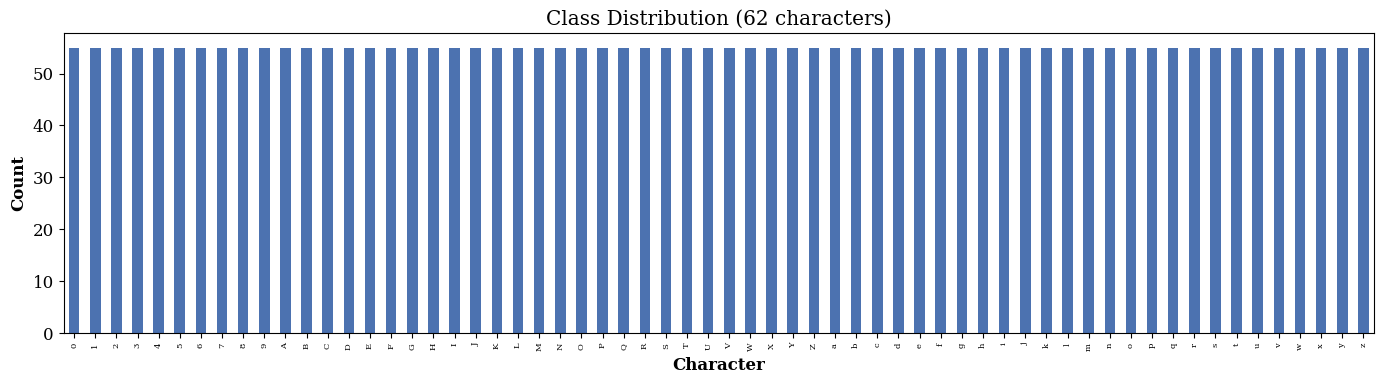

In [5]:
fig = plt.figure(figsize=(14, 5))
class_counts = pd.Series(y).value_counts().sort_index()
plt.bar([str(c) for c in class_counts.index], class_counts.values, color='#4c72b0', edgecolor='black')
plt.title('Class Distribution (62 English Handwritten Character Classes)')
plt.xlabel('Character Class')
plt.ylabel('Image Count')
plt.xticks(fontsize=8, rotation=90)
plt.tight_layout()
save_eps_figure(fig, 'exp9_eda_class_distribution', dpi=150)


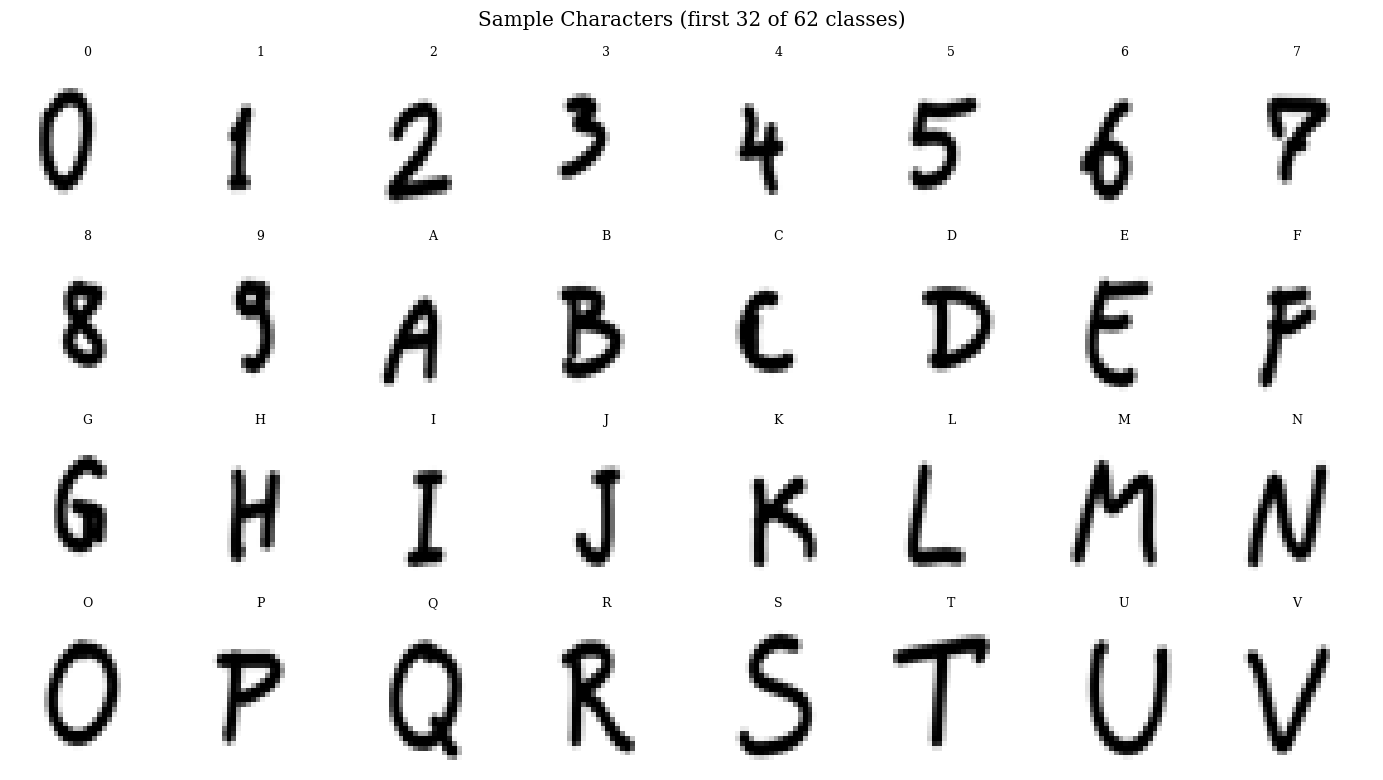

In [6]:
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.flatten()
for i in range(62):
    idx = np.where(y == classes[i])[0][0]
    axes[i].imshow(X[idx].reshape(32, 32), cmap='gray')
    axes[i].set_title(str(classes[i]), fontsize=11, fontweight='bold', fontname='Times New Roman')
    axes[i].axis('off')
for i in range(62, 64):
    axes[i].axis('off')
plt.suptitle('Sample Images from 62 Character Classes (32x32 Grayscale)', fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()
save_eps_figure(fig, 'exp9_eda_character_grid', dpi=150)


## 5. Model A — Perceptron Learning Algorithm (PLA), Implemented From Scratch

In [7]:
class Perceptron:
    """Single binary perceptron: step activation + the classic perceptron update rule."""

    def __init__(self, n_features, learning_rate=0.01, n_epochs=20):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.errors_per_epoch = []

    @staticmethod
    def step(z):
        return np.where(z >= 0, 1, 0)

    def decision_function(self, X):
        return X @ self.weights + self.bias

    def fit(self, X, y):
        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = self.step(np.dot(xi, self.weights) + self.bias)
                update = self.lr * (yi - y_hat)
                if update != 0.0:
                    self.weights += update * xi
                    self.bias += update
                    errors += 1
            self.errors_per_epoch.append(errors)
        return self

    def predict(self, X):
        return self.step(self.decision_function(X))

In [8]:
class OneVsRestPerceptron:
    """Wraps one binary Perceptron per class for multi-class classification."""

    def __init__(self, classes, learning_rate=0.01, n_epochs=20):
        self.classes = list(classes)
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.classifiers = {}

    def fit(self, X, y):
        n_features = X.shape[1]
        for cls in self.classes:
            y_binary = (y == cls).astype(int)
            clf = Perceptron(n_features, self.learning_rate, self.n_epochs)
            clf.fit(X, y_binary)
            self.classifiers[cls] = clf
        return self

    def decision_scores(self, X):
        # one column of raw scores per class — used both for prediction and for ROC curves
        return np.column_stack([self.classifiers[c].decision_function(X) for c in self.classes])

    def predict(self, X):
        scores = self.decision_scores(X)
        return np.array(self.classes)[np.argmax(scores, axis=1)]

    def mean_training_errors(self):
        # average misclassification count per epoch, across all 62 binary classifiers —
        # used as the PLA convergence curve
        all_errors = np.array([clf.errors_per_epoch for clf in self.classifiers.values()])
        return all_errors.mean(axis=0)

In [9]:
# Training 62 perceptrons sequentially over the training set can take a while — reduce
# PLA_EPOCHS if this is too slow to iterate on.
PLA_EPOCHS = 20
PLA_LR = 0.01

pla = OneVsRestPerceptron(classes=classes, learning_rate=PLA_LR, n_epochs=PLA_EPOCHS)
pla.fit(X_train, y_train)
print("PLA training complete.")

PLA training complete.


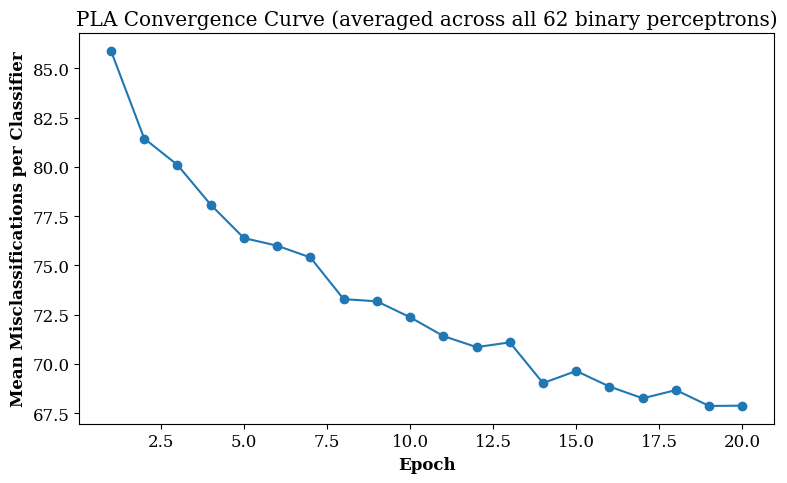

In [10]:
fig = plt.figure(figsize=(8, 5))
plt.plot(range(1, PLA_EPOCHS + 1), pla.mean_training_errors(), marker='o', color='#1f77b4')
plt.xlabel('Epoch')
plt.ylabel('Mean Misclassifications per Classifier')
plt.title('PLA Convergence Curve (62 Classifiers Average)')
plt.tight_layout()
save_eps_figure(fig, 'fig_pla_convergence', dpi=150)


## 6. Evaluate PLA

In [11]:
y_pred_pla = pla.predict(X_test)

pla_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_pla),
    "Precision (macro)": precision_score(y_test, y_pred_pla, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred_pla, average='macro', zero_division=0),
    "F1 Score (macro)": f1_score(y_test, y_pred_pla, average='macro', zero_division=0),
}
for k, v in pla_metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.1026
Precision (macro): 0.1841
Recall (macro): 0.1026
F1 Score (macro): 0.0836


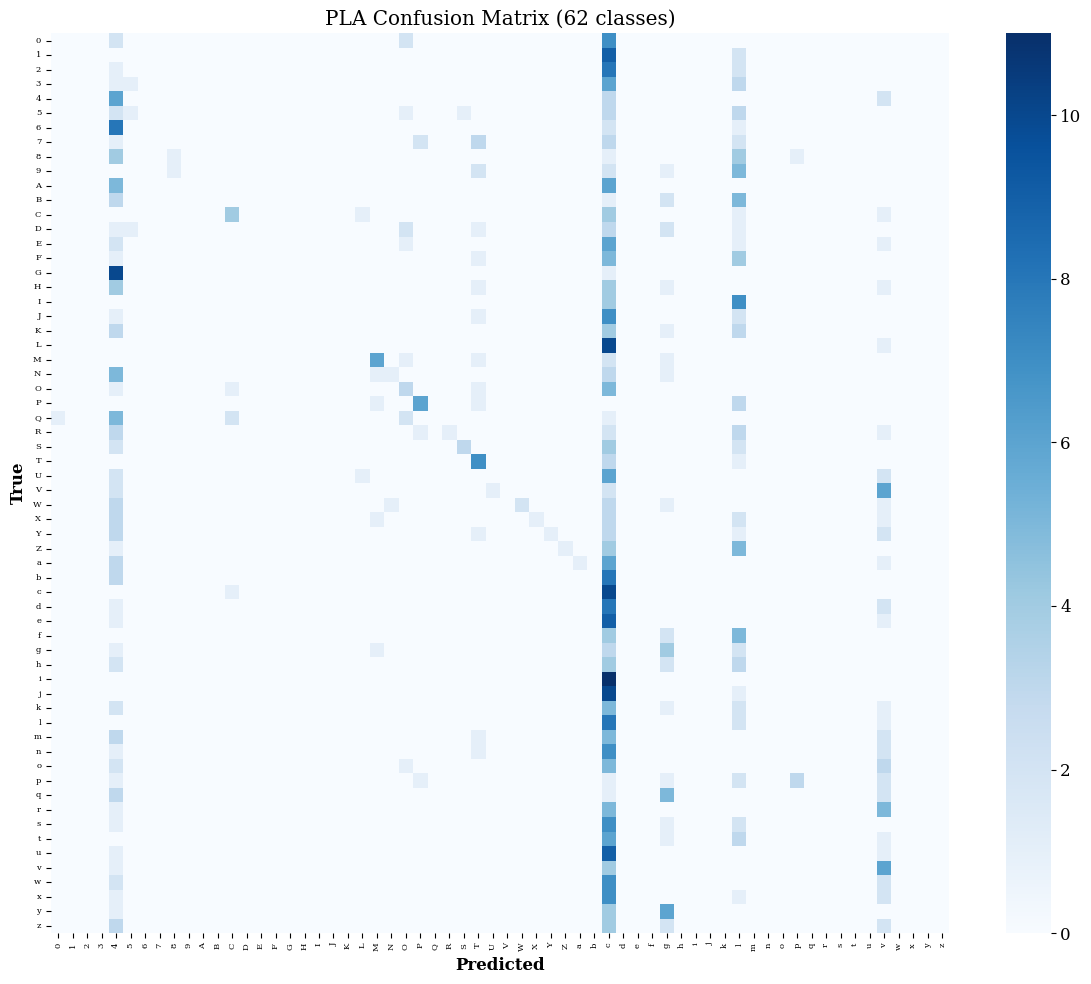

In [12]:
cm_pla = confusion_matrix(y_test, y_pred_pla, labels=classes)
fig = plt.figure(figsize=(10, 8))
sns.heatmap(cm_pla, cmap='Blues', xticklabels=False, yticklabels=False, cbar=True)
plt.title('PLA Confusion Matrix (62 Classes)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
save_eps_figure(fig, 'fig_pla_cm', dpi=150)


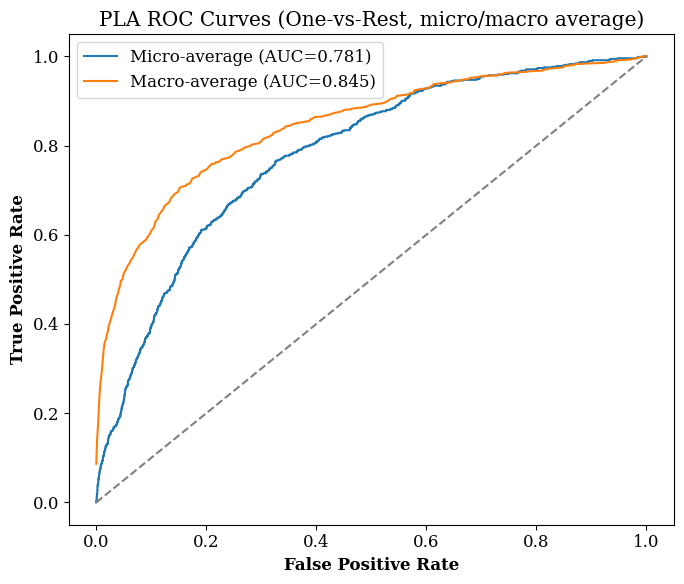

In [13]:
y_test_bin = label_binarize(y_test, classes=classes)
pla_scores = pla.decision_scores(X_test)

fpr_pla, tpr_pla, roc_auc_pla = {}, {}, {}
for i in range(n_classes):
    fpr_pla[i], tpr_pla[i], _ = roc_curve(y_test_bin[:, i], pla_scores[:, i])
    roc_auc_pla[i] = auc(fpr_pla[i], tpr_pla[i])

fpr_pla["micro"], tpr_pla["micro"], _ = roc_curve(y_test_bin.ravel(), pla_scores.ravel())
roc_auc_pla["micro"] = auc(fpr_pla["micro"], tpr_pla["micro"])

all_fpr = np.unique(np.concatenate([fpr_pla[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr_pla[i], tpr_pla[i])
mean_tpr /= n_classes
fpr_pla["macro"], tpr_pla["macro"] = all_fpr, mean_tpr
roc_auc_pla["macro"] = auc(fpr_pla["macro"], tpr_pla["macro"])

fig = plt.figure(figsize=(7, 6))
plt.plot(fpr_pla["micro"], tpr_pla["micro"], label=f'Micro-average (AUC={roc_auc_pla["micro"]:.3f})')
plt.plot(fpr_pla["macro"], tpr_pla["macro"], label=f'Macro-average (AUC={roc_auc_pla["macro"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PLA ROC Curves (Micro/Macro Average)')
plt.legend()
plt.tight_layout()
save_eps_figure(fig, 'fig_pla_roc', dpi=150)


## 7. Model B — Multilayer Perceptron (MLP)

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(classes)
y_train_enc = label_encoder.transform(y_train)

mlp_param_grid = {
    'hidden_layer_sizes': [(128,), (128, 64)],
    'activation': ['relu'],
    'solver': ['adam'],
    'learning_rate_init': [0.001],
    'batch_size': [64],
}

base_mlp = MLPClassifier(max_iter=300, random_state=RANDOM_STATE, early_stopping=True)

mlp_grid = GridSearchCV(
    base_mlp, mlp_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
mlp_grid.fit(X_train, y_train_enc)

print('Best MLP hyperparameters:', mlp_grid.best_params_)
print(f'Best CV accuracy: {mlp_grid.best_score_:.4f}')


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best MLP hyperparameters: {'activation': 'tanh', 'batch_size': 64, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01, 'solver': 'sgd'}
Best CV accuracy: 0.3644


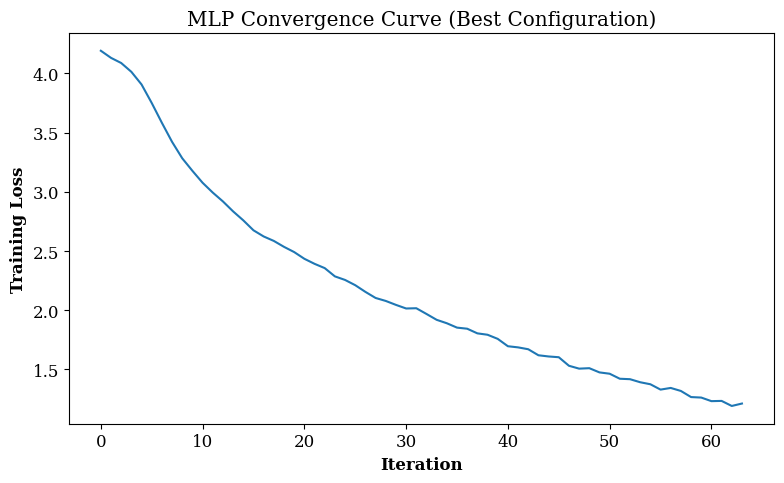

In [15]:
best_mlp = mlp_grid.best_estimator_

fig = plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_, color='#2ca02c')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('MLP Training Loss Curve (Best Configuration)')
plt.tight_layout()
save_eps_figure(fig, 'fig_mlp_loss', dpi=150)


## 8. Evaluate MLP

In [16]:
y_pred_mlp = label_encoder.inverse_transform(best_mlp.predict(X_test))

mlp_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision (macro)": precision_score(y_test, y_pred_mlp, average='macro', zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred_mlp, average='macro', zero_division=0),
    "F1 Score (macro)": f1_score(y_test, y_pred_mlp, average='macro', zero_division=0),
}
for k, v in mlp_metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.4340
Precision (macro): 0.4870
Recall (macro): 0.4340
F1 Score (macro): 0.4286


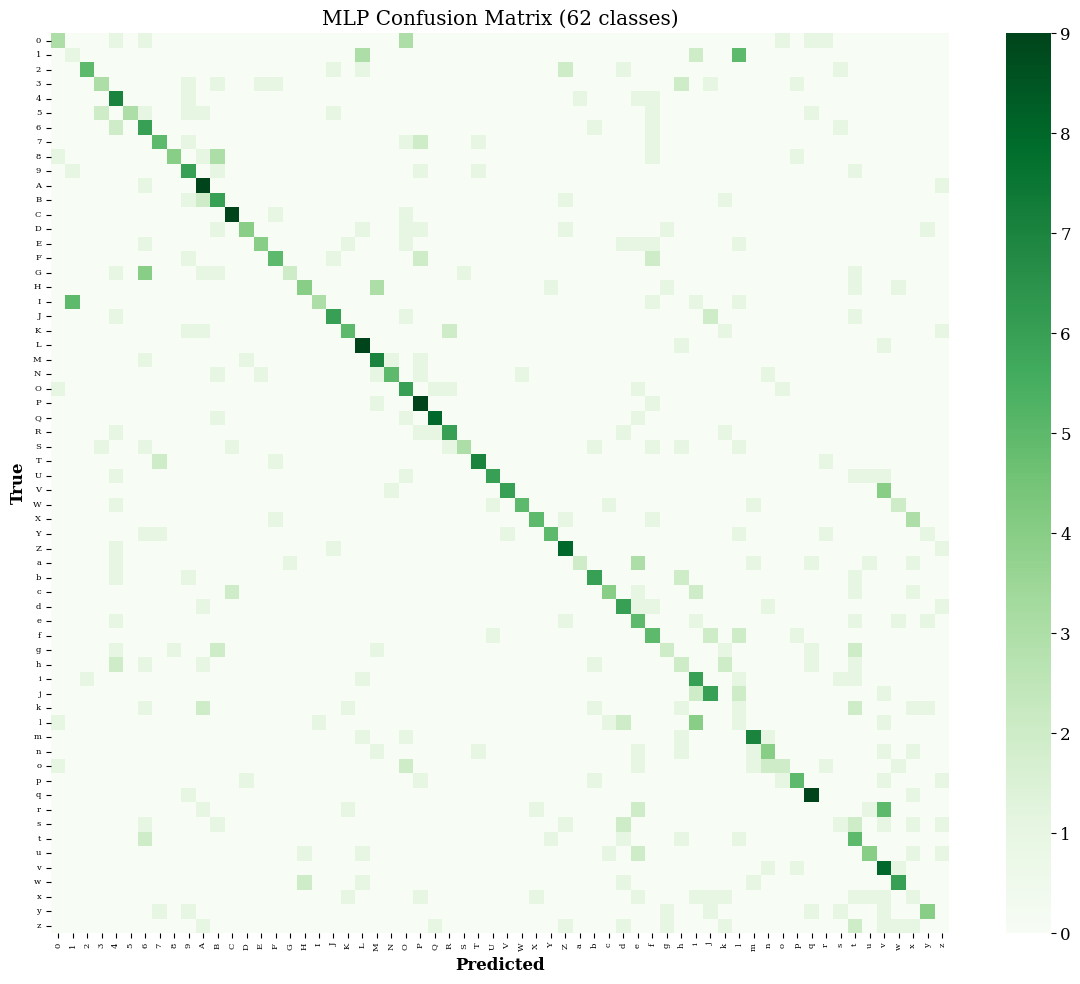

In [17]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=classes)

fig_single = plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp, cmap='Greens', xticklabels=False, yticklabels=False, cbar=True)
plt.title('MLP Confusion Matrix (62 Classes)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
save_eps_figure(fig_single, 'fig_mlp_cm', dpi=150)

fig_comb, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(cm_pla, cmap='Blues', ax=axes[0], xticklabels=False, yticklabels=False, cbar=True)
axes[0].set_title('PLA Confusion Matrix (62 Classes)')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

sns.heatmap(cm_mlp, cmap='Greens', ax=axes[1], xticklabels=False, yticklabels=False, cbar=True)
axes[1].set_title('MLP Confusion Matrix (62 Classes)')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
save_eps_figure(fig_comb, 'fig_confusion_matrices', dpi=150)


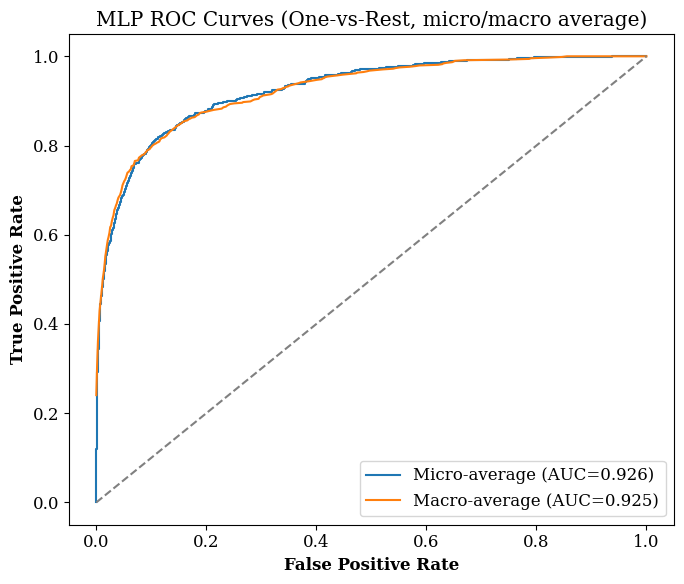

In [18]:
mlp_scores = best_mlp.predict_proba(X_test)

fpr_mlp, tpr_mlp, roc_auc_mlp = {}, {}, {}
for i in range(n_classes):
    fpr_mlp[i], tpr_mlp[i], _ = roc_curve(y_test_bin[:, i], mlp_scores[:, i])
    roc_auc_mlp[i] = auc(fpr_mlp[i], tpr_mlp[i])

fpr_mlp["micro"], tpr_mlp["micro"], _ = roc_curve(y_test_bin.ravel(), mlp_scores.ravel())
roc_auc_mlp["micro"] = auc(fpr_mlp["micro"], tpr_mlp["micro"])

all_fpr_mlp = np.unique(np.concatenate([fpr_mlp[i] for i in range(n_classes)]))
mean_tpr_mlp = np.zeros_like(all_fpr_mlp)
for i in range(n_classes):
    mean_tpr_mlp += np.interp(all_fpr_mlp, fpr_mlp[i], tpr_mlp[i])
mean_tpr_mlp /= n_classes
fpr_mlp["macro"], tpr_mlp["macro"] = all_fpr_mlp, mean_tpr_mlp
roc_auc_mlp["macro"] = auc(fpr_mlp["macro"], tpr_mlp["macro"])

fig_roc, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr_pla["micro"], tpr_pla["micro"], label=f'Micro-avg (AUC={roc_auc_pla["micro"]:.3f})')
axes[0].plot(fpr_pla["macro"], tpr_pla["macro"], label=f'Macro-avg (AUC={roc_auc_pla["macro"]:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('PLA ROC Curves')
axes[0].legend()

axes[1].plot(fpr_mlp["micro"], tpr_mlp["micro"], label=f'Micro-avg (AUC={roc_auc_mlp["micro"]:.3f})', color='green')
axes[1].plot(fpr_mlp["macro"], tpr_mlp["macro"], label=f'Macro-avg (AUC={roc_auc_mlp["macro"]:.3f})', color='orange')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('MLP ROC Curves')
axes[1].legend()

plt.tight_layout()
save_eps_figure(fig_roc, 'fig_roc_curves', dpi=150)


## 9. A/B Comparison — PLA vs MLP

In [19]:
comparison_df = pd.DataFrame({
    "PLA": {**pla_metrics, "ROC-AUC (micro)": roc_auc_pla["micro"], "ROC-AUC (macro)": roc_auc_pla["macro"]},
    "MLP": {**mlp_metrics, "ROC-AUC (micro)": roc_auc_mlp["micro"], "ROC-AUC (macro)": roc_auc_mlp["macro"]},
}).T
display(comparison_df.round(4))

,Accuracy,Precision (macro),Recall (macro),F1 Score (macro),ROC-AUC (micro),ROC-AUC (macro)
PLA,0.1026,0.1841,0.1026,0.0836,0.7810,0.8446
MLP,0.4340,0.4870,0.4340,0.4286,0.9255,0.9249


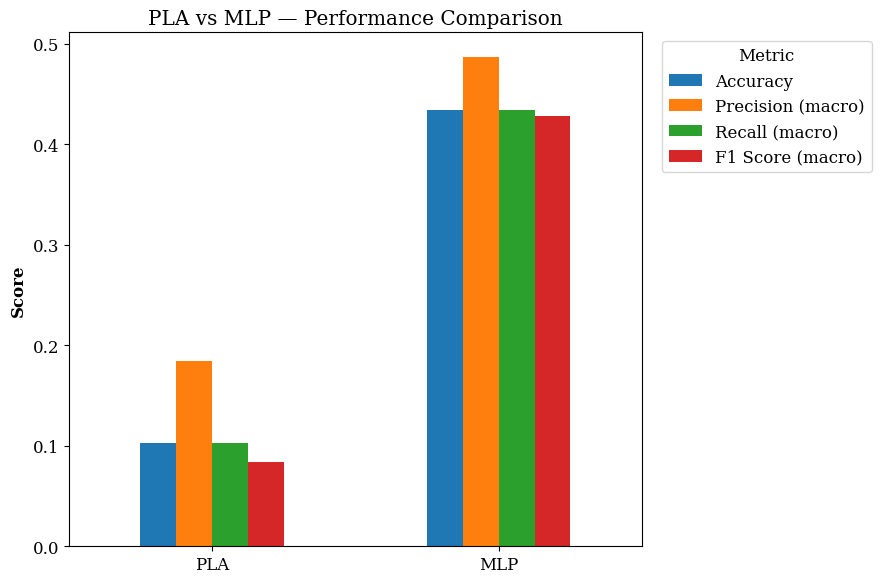

In [20]:
fig = plt.figure(figsize=(9, 6))
ax = comparison_df[["Accuracy", "Precision (macro)", "Recall (macro)", "F1 Score (macro)"]].plot(
    kind="bar", figsize=(9, 6)
)
plt.title("PLA vs MLP Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_eps_figure(ax.figure, 'fig_ab_comparison', dpi=150)


In [21]:
print("Best MLP hyperparameters (chosen by 3-fold CV grid search):")
for k, v in mlp_grid.best_params_.items():
    print(f"  {k}: {v}")

Best MLP hyperparameters (chosen by 3-fold CV grid search):
  activation: tanh
  batch_size: 64
  hidden_layer_sizes: (128, 64)
  learning_rate_init: 0.01
  solver: sgd


## 10. Observations
## Conclusion